In [51]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

In [52]:
mS = 10**7
mP = 10**4
mA = 1.0
G  = 1.0
R = 20.0
xS = 0.0
xP = 20.0
total_mass = mS + mP
rs = np.array([xS,0])
rp = np.array([xP,0])
rcm = (rp*mP + rs*mS)/(mP + mS)
xS = 0-rcm[0]
yS = 0.0
xP = 20 - rcm[0]
yP = 0.0
print(rcm)
print(xS)

[0.01998002 0.        ]
-0.01998001998001998


In [57]:
mu = mS*mP/(mS + mP)
theta_rad = np.deg2rad(45)
xA = R*np.cos(theta_rad)
yA = R*np.sin(theta_rad)
w = np.sqrt(G*(mS*mP)/(R**3*mu))


vxS = 0
vyS = w*np.abs(xS)
vxP = 0
vyP = -w*xP

vxA = -w*xA
vyA = w*yA

y0 = np.array([xS,yS,vxS,vyS,xP,yP,vxP,vyP,xA,yA,vxA,vyA])

print(y0)

[-1.99800200e-02  0.00000000e+00  0.00000000e+00  7.06753493e-01
  1.99800200e+01  0.00000000e+00  0.00000000e+00 -7.06753493e+02
  1.41421356e+01  1.41421356e+01 -5.00249938e+02  5.00249938e+02]


In [58]:
def threebodyODE(t,y):
    global G,mS,mP,mA

    rS = y[0:2]
    rP = y[4:6]
    rA = y[8:10]
    vS = y[2:4]
    vP = y[6:8]
    vA = y[10:12]
    drdt1 = vS
    drdt2 = vP
    drdt3 = vA
    
    Fps = -mS*mP*G/np.linalg.norm(rP-rS)**3*(rp-rs)
    Fas = -mS*mA*G/np.linalg.norm(rA-rS)**3*(rA-rS)
    a = -(Fps + Fas)/mS
    dvdt1 = a

    Fsp = -mS*mP*G/np.linalg.norm(rS-rP)*(rS-rP)
    Fap = -mA*mP*G/np.linalg.norm(rA-rP)*(rA-rP)
    a = -(Fsp+Fap)/mS
    dvdt2 = a

    Fsa = -mS*mA*G/np.linalg.norm(rS-rA)*(rS-rA)
    Fpa = -mS*mA*G/np.linalg.norm(rP-rA)*(rP-rA)
    a = -(Fsa+Fpa)/mS
    dvdt3 = a
    return np.concatenate((drdt1,drdt2,drdt3,dvdt1,dvdt2,dvdt3))

In [59]:
def TransformIntoPlanetFrame(xp,yp,x,y):
    phi = np.arctan2(yp,xp)
    s = np.sin(phi)
    c = np.cos(phi)

    A = np.array([[c,s],[-s,c]])

    r_relative  = np.array([x - xp,y - yp])
    rt = A.dot(r_relative) # matrix vector multiplication

    xt = rt[0]
    yt = rt[1]
    
    return xt, yt #return the transformed coordinates

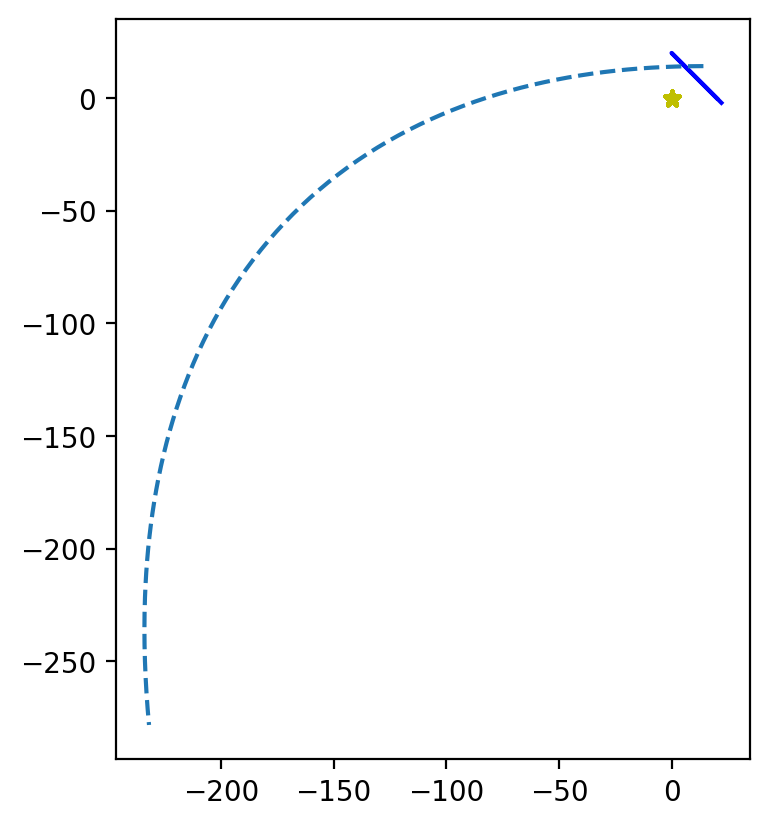

In [60]:
y = np.copy(y0)
rs = y[0:2]
rp = y[4:6]
r_mag = np.sqrt((rs[0]-rp[0])**2 + (rs[1] - rp[1])**2)
P = np.sqrt((4*np.pi**2)/(G*(mS + mP))*r_mag**3)
tmax = P/4
steps = 1000
dt = P/steps
xpt = [y[4]]
ypt = [y[5]]
xst = [y[0]]
yst = [y[1]]
xat = [y[8]]
yat = [y[9]]
t = 0
while (t<tmax):
    xst.append(y[0])
    yst.append(y[1])
    xpt.append(y[5])
    ypt.append(y[4])
    xat.append(y[8])
    yat.append(y[9])
    
    f1 = threebodyODE(t       ,y          )
    f2 = threebodyODE(t+dt/2.0,y+f1*dt/2.0)
    f3 = threebodyODE(t+dt/2.0,y+f2*dt/2.0)
    f4 = threebodyODE(t+dt    ,y+f3*dt    )

    y = y + (f1 + 2.0*f2 + 2.0*f3 + f4) / 6.0 * dt
    t = t + dt
plt.plot(xpt,ypt,'b-')
plt.plot(xst,yst,'y*')
plt.plot(xat,yat,linestyle='dashed')

plt.gca().set_aspect('equal', adjustable = 'box')
plt.show()

In [61]:
#I cannot figure out why the planet is not traveling in a circular motion, I have tried many things to fix it and I can't come to a solution.
#The path of the asteroid is the dashed blue line, the asteroid and the planet can be told abart by their starting positions and by the attributes of their lines.
#As you can see, the planet starts adjacent to the sun, marked as the yello star, and the asteroid starts 45 degrees ahead of it.
#The path of the sun appears to just be a dot becuase the sun only moves a tidy, negligable ammount.

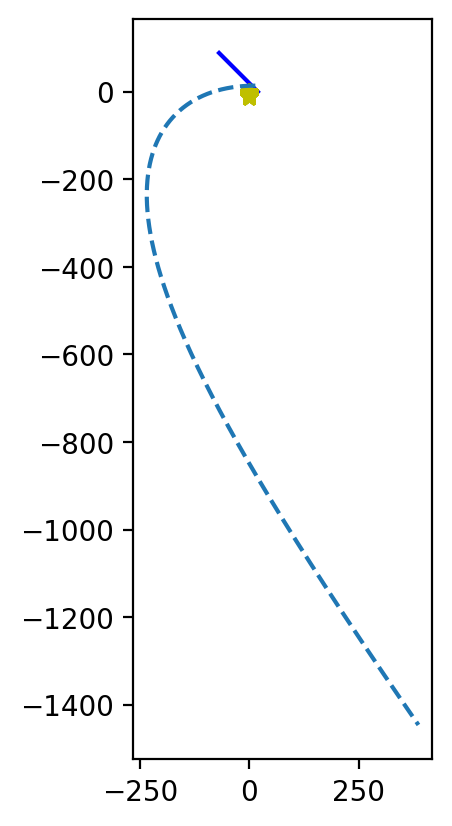

In [62]:
y = np.copy(y0)
rs = y[0:2]
rp = y[4:6]
r_mag = np.sqrt((rs[0]-rp[0])**2 + (rs[1] - rp[1])**2)
P = np.sqrt((4*np.pi**2)/(G*(mS + mP))*r_mag**3)
tmax = P
steps = 1000
dt = P/steps
xpt = [y[4]]
ypt = [y[5]]
xst = [y[0]]
yst = [y[1]]
xat = [y[8]]
yat = [y[9]]
t = 0
while (t<tmax):
    xst.append(y[0])
    yst.append(y[1])
    xpt.append(y[4])
    ypt.append(y[5])
    xat.append(y[8])
    yat.append(y[9])
    
    f1 = threebodyODE(t       ,y          )
    f2 = threebodyODE(t+dt/2.0,y+f1*dt/2.0)
    f3 = threebodyODE(t+dt/2.0,y+f2*dt/2.0)
    f4 = threebodyODE(t+dt    ,y+f3*dt    )

    y = y + (f1 + 2.0*f2 + 2.0*f3 + f4) / 6.0 * dt
    t = t + dt
plt.plot(xpt,ypt,'b-')
plt.plot(xst,yst,'y*')
plt.plot(xat,yat,linestyle='dashed')

plt.gca().set_aspect('equal', adjustable = 'box')
plt.show()

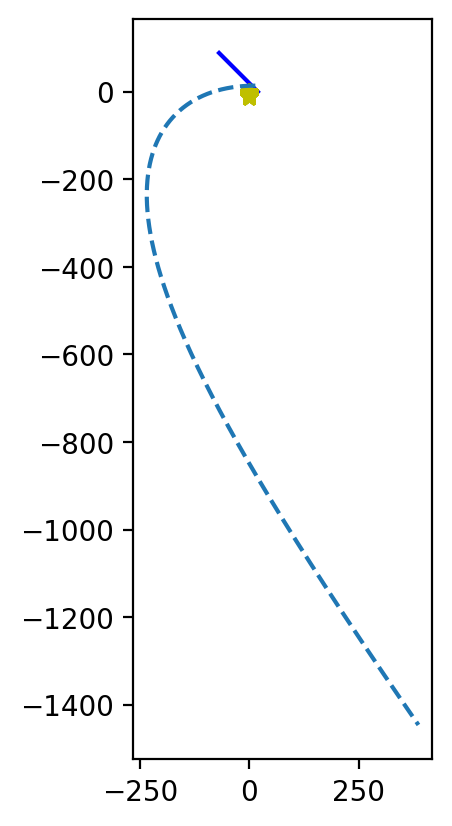

In [63]:
y = np.copy(y0)
rs = y[0:2]
rp = y[4:6]
r_mag = np.sqrt((rs[0]-rp[0])**2 + (rs[1] - rp[1])**2)
P = np.sqrt((4*np.pi**2)/(G*(mS + mP))*r_mag**3)
tmax = P
steps = 1000
dt = P/steps
xpt = [y[4]]
ypt = [y[5]]
xst = [y[0]]
yst = [y[1]]
xat = [y[8]]
yat = [y[9]]
t = 0
while (t<tmax):
    
    xt_A = TransformIntoPlanetFrame(y[4],y[5],y[8],y[9])
    
    xst.append(y[0])
    yst.append(y[1])
    xpt.append(y[4])
    ypt.append(y[5])
    xat.append(y[8])
    yat.append(y[9])
    
    
    
    f1 = threebodyODE(t       ,y          )
    f2 = threebodyODE(t+dt/2.0,y+f1*dt/2.0)
    f3 = threebodyODE(t+dt/2.0,y+f2*dt/2.0)
    f4 = threebodyODE(t+dt    ,y+f3*dt    )

    y = y + (f1 + 2.0*f2 + 2.0*f3 + f4) / 6.0 * dt
    t = t + dt
plt.plot(xpt,ypt,'b-')
plt.plot(xst,yst,'y*')
plt.plot(xat,yat,linestyle='dashed')

plt.gca().set_aspect('equal', adjustable = 'box')
plt.show()